In [1]:
import re
import os, sys
import numpy as np 
import glob
import pandas as pd 
import IPython.display as ipd

%matplotlib inline 
import matplotlib.pyplot as plt

In [ ]:
# Get text 
text_df = pd.read_csv('/om2/data/public/GigaSpeech/data/text',
                      header=None, names=['wav_filename', 'transcript'],
                      delimiter = "\t",
                      dtype='str')

In [3]:
text_df.head(10)

,wav_filename,transcript
0,POD0000000001_S0000008,DOUGLAS MCGRAY IS GOING TO BE OUR GUIDE YOU WA...
1,POD0000000001_S0000010,AH ITALIAN <QUESTIONMARK> AND AND THEN YOU HAV...
2,POD0000000001_S0000011,DOUG MCGRAY IS A JOURNALIST MY NAME IS DOUGLAS...
3,POD0000000001_S0000012,AH YOU LEAVE WITH CASH MINUS A THREE PERCENT F...
4,POD0000000001_S0000013,AND PAYDAY LENDING IS WHEN YOU DON'T HAVE ANY ...
5,POD0000000001_S0000015,WHAT MAY SURPRISE YOU THOUGH <COMMA> IF YOU HA...
6,POD0000000001_S0000016,THE ABSENCE OF THE BANK-LIKE TRAPPINGS PLUSH C...
7,POD0000000001_S0000017,WHEN DOUG MCGRAY WENT OF A TOUR OF A BRANCH WI...
8,POD0000000001_S0000018,NIX POINTED OUT THE DESIGN CHOICES HE MADE YOU...
9,POD0000000001_S0000019,AND HE SAID <COMMA> YOU KNOW <COMMA> IF YOU GO...


In [4]:
"x  good".split()

['x', 'good']

In [5]:
good_text = text_df[~text_df.isna().any(axis=1)]

In [6]:
# strip punctuation & garbage:

garbage_utterance_tags = "<SIL>|<MUSIC>|<NOISE>|<OTHER>"
punctuation_tags = "<COMMA>|<EXCLAMATIONPOINT>|<PERIOD>|<QUESTIONMARK>"

# good_text.text = good_text.transcript.apply(lambda str_: re.sub(punctuation_tags, "", str_))

good_text['text'] = good_text.transcript.str.replace(punctuation_tags, "", case=False, regex=True)

<ipython-input-6-561322b4e46d>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_text['text'] = good_text.transcript.str.replace(punctuation_tags, "", case=False, regex=True)


In [7]:
good_text.iloc[0].transcript, good_text.iloc[0].text, 

('DOUGLAS MCGRAY IS GOING TO BE OUR GUIDE YOU WALK THROUGH THE DOOR <COMMA> YOU SEE THE RED CARPETING <COMMA> YOU SEE SOMEONE IN A SUIT <PERIOD> THEY MAY BE GREETING YOU <PERIOD>',
 'DOUGLAS MCGRAY IS GOING TO BE OUR GUIDE YOU WALK THROUGH THE DOOR  YOU SEE THE RED CARPETING  YOU SEE SOMEONE IN A SUIT  THEY MAY BE GREETING YOU ')

In [8]:
good_text.shape, text_df.shape

((8315356, 3), (8315357, 2))

In [9]:
len(good_text)

8315356

In [10]:

def get_counts(to_count):
    if type(to_count) == pd.core.series.Series:
        counts = to_count.str.split().explode().value_counts()
    else: # is dataframe
        counts = to_count.transcript.str.split().explode().value_counts()
    return counts

def get_cumprop(to_count, count=True, return_counts=True):
    '''if get_counts is true, to_count is df
    to be counted. Else it is already a 
    pd.Series of counted indices and values. 
    '''
    if count:
        counts = get_counts(to_count)
    else:
        counts = to_count
    counts = counts.sort_values(ascending=False)
    cumsum = counts.values.cumsum()
    cumprop = cumsum / np.nansum(counts)
    if count == False:
        return cumprop
    else:
        return cumprop, counts

Alternate method to count word frequency

In [11]:
%%time

from collections import Counter
results = Counter()

good_text['text'].apply(lambda x: results.update(x.split()))

CPU times: user 40.1 s, sys: 449 ms, total: 40.5 s
Wall time: 40.5 s


0          None
1          None
2          None
3          None
4          None
           ... 
8315352    None
8315353    None
8315354    None
8315355    None
8315356    None
Name: text, Length: 8315356, dtype: object

In [12]:
results.most_common()

[('THE', 5210898),
 ('AND', 3698595),
 ('TO', 2992226),
 ('OF', 2785806),
 ('A', 2337832),
 ('THAT', 1953291),
 ('IN', 1686169),
 ('I', 1627071),
 ('YOU', 1610997),
 ('IS', 1242867),
 ('IT', 1199499),
 ('WAS', 899413),
 ('FOR', 855033),
 ('SO', 844028),
 ('THIS', 819619),
 ('WE', 776897),
 ('BUT', 694190),
 ('WITH', 688810),
 ('ON', 685180),
 ('HAVE', 647004),
 ('HE', 643868),
 ('AS', 606406),
 ('BE', 586990),
 ('ARE', 543497),
 ('THEY', 540967),
 ('NOT', 531907),
 ('AT', 497946),
 ('LIKE', 485862),
 ('WHAT', 471777),
 ('KNOW', 417971),
 ('HIS', 416009),
 ('ALL', 414717),
 ('ABOUT', 403972),
 ("IT'S", 403735),
 ('ONE', 397854),
 ('OR', 395503),
 ('HAD', 391637),
 ('IF', 386745),
 ('MY', 381511),
 ('DO', 378818),
 ('FROM', 374776),
 ('THERE', 352353),
 ('JUST', 350219),
 ('CAN', 347631),
 ('YOUR', 333090),
 ('BY', 320574),
 ('AH', 302251),
 ('ME', 300643),
 ('AN', 298929),
 ('WHEN', 296529),
 ('WERE', 289027),
 ('PEOPLE', 286975),
 ('WHICH', 282267),
 ('HER', 280912),
 ('SHE', 280186),


In [11]:
%%time 
all_cumprop, all_counts = get_cumprop(good_text.text)


CPU times: user 1min 7s, sys: 5.78 s, total: 1min 13s
Wall time: 1min 13s


In [12]:

total_vocab = len(all_counts)
total_tokens = all_counts.values.sum()

print(f"Combined vocab size is {total_vocab} with {total_tokens} tokens")

Combined vocab size is 406382 with 106129150 tokens


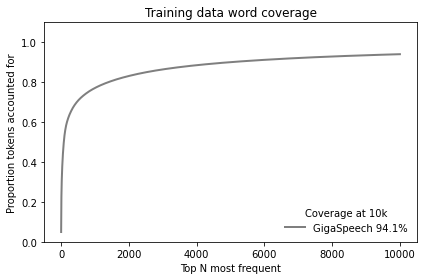

In [13]:
cutoff = 10000

plt.plot(all_cumprop[:cutoff], 'k', alpha=0.5, linewidth=2,
         label=f"GigaSpeech {(all_cumprop[cutoff] * 100).round(1)}%")


plt.ylim(0,1.1)
plt.legend(frameon=False, loc='lower right', title='Coverage at 10k')
plt.title("Training data word coverage")
plt.xlabel("Top N most frequent")
plt.ylabel("Proportion tokens accounted for")
plt.tight_layout()


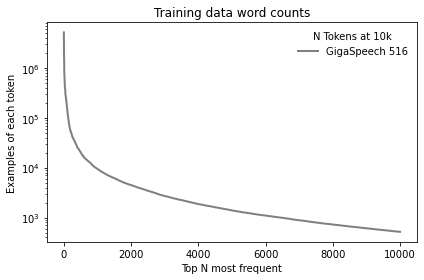

In [14]:

cutoff = 10000

plt.plot(all_counts.values[:cutoff], 'k', alpha=0.5, linewidth=2,
         label=f"GigaSpeech {all_counts.values[cutoff]}")

# plt.ylim(0,1.1)
plt.yscale('log')
plt.legend(frameon=False, loc='upper right', title='N Tokens at 10k')
plt.title("Training data word counts")
plt.xlabel("Top N most frequent")
plt.ylabel("Examples of each token")
plt.tight_layout()


# Look at durations in each split

In [5]:
# Get text 
train_df = pd.read_csv('/om2/data/public/GigaSpeech/data/XL.csv',
                      delimiter = "\t", usecols=['wav_len'],
                      dtype='int')

In [9]:
dev_df = pd.read_csv('/om2/data/public/GigaSpeech/data/DEV.csv',
                      delimiter = "\t", usecols=['wav_len'],
                      dtype='int')

In [10]:
test_df = pd.read_csv('/om2/data/public/GigaSpeech/data/TEST.csv',
                      delimiter = "\t",usecols=['wav_len'],
                      dtype='int')

In [ ]:
import seaborn as sns


In [21]:
concatenated = pd.concat([train_df.assign(dataset='train'),
                          dev_df.assign(dataset='dev'),
                          test_df.assign(dataset='test')])


In [22]:
concatenated['wav_len'] = concatenated.wav_len.div(1000)

<AxesSubplot:xlabel='dataset', ylabel='wav_len'>

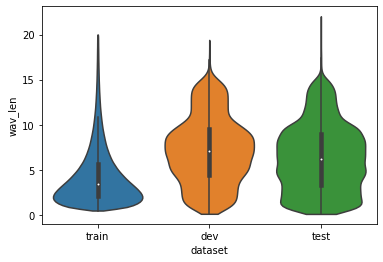

In [23]:
sns.violinplot(x="dataset", y="wav_len",
            data=concatenated,
            cut=0,scale="width")

# Get top 10k GigaSpeech word tokens 

In [15]:
top_words = all_counts.index.to_list()
# top_words[:1000]

In [16]:

filtered_top = []
for word in top_words:
    if word.isalpha():
        if len(word) > 1:
            filtered_top.append(word)
        else:
            if word == 'A' or word == 'I':
                filtered_top.append(word)

In [17]:
len(filtered_top)

top = filtered_top[:10000] # wave top 10k

### Save as vocab

In [24]:
# out_name = '../tests/sample_data/gigaspeech_words-10k.vocab'
# with open(out_name, "w") as f:
#             f.write("\n".join(top))

In [20]:
# out_name = '../corpus/gigaspeech_top_200.txt'


# with open(out_name, "w") as f:
#             f.write("\n".join(top[:200]))

In [21]:
print(top[:200])

['THE', 'AND', 'TO', 'OF', 'A', 'THAT', 'IN', 'I', 'YOU', 'IS', 'IT', 'WAS', 'FOR', 'SO', 'THIS', 'WE', 'BUT', 'WITH', 'ON', 'HAVE', 'HE', 'AS', 'BE', 'ARE', 'THEY', 'NOT', 'AT', 'LIKE', 'WHAT', 'KNOW', 'HIS', 'ALL', 'ABOUT', 'ONE', 'OR', 'HAD', 'IF', 'MY', 'DO', 'FROM', 'THERE', 'JUST', 'CAN', 'YOUR', 'BY', 'AH', 'ME', 'AN', 'WHEN', 'WERE', 'PEOPLE', 'WHICH', 'HER', 'SHE', 'OUT', 'THINK', 'WOULD', 'UP', 'THEN', 'OUR', 'WHO', 'THEIR', 'THEM', 'MORE', 'NOW', 'SOME', 'HOW', 'VERY', 'BECAUSE', 'WILL', 'BEEN', 'UM', 'GOING', 'REALLY', 'NO', 'TIME', 'HAS', 'HIM', 'GET', 'THESE', 'SAID', 'INTO', 'RIGHT', 'HERE', 'GO', 'OTHER', 'WELL', 'SEE', 'TWO', 'COULD', 'WHERE', 'WAY', 'US', 'ALSO', 'THOSE', 'WANT', 'SAY', 'THINGS', 'YEAH', 'DID', 'MUCH', 'BACK', 'FIRST', 'MAKE', 'OVER', 'THAN', 'GOOD', 'LITTLE', 'ANY', 'KIND', 'SOMETHING', 'EVEN', 'ONLY', 'LOT', 'NEW', 'GOT', 'DOWN', 'THING', 'BEING', 'ACTUALLY', 'WORK', 'COME', 'THROUGH', 'MANY', 'LOOK', 'TAKE', 'MOST', 'YEARS', 'BEFORE', 'AFTER', 'SHO